# 01 — Exploratory data analysis of the synthetic program cohort

**Purpose.** Understand the synthetic hypertension/diabetes program data before modelling:
who is registered, how often visits are missed, who is overdue or lost to follow-up, how well
blood pressure is controlled, what phone calls achieve, and what patients write back by SMS.

**Data.** PostgreSQL database `d_clinic`, tables named after Simple's schema, loaded by `make seed`.
All patients are synthetic. Definitions follow `docs/definitions.md`.

**Privacy note.** This notebook reads only structured, non-identifying columns. It never selects
`full_name`, phone numbers, or street addresses.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "D_Clinic_Backend").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "D_Clinic_Backend"))
from app.db import engine  # noqa: E402

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 3.5)
AS_OF = pd.Timestamp.today().normalize()

def q(sql: str, **params) -> pd.DataFrame:
    with engine.connect() as c:
        return pd.read_sql(text(sql), c, params=params)

print("as of", AS_OF.date())

as of 2026-09-26


## 1. Cohort overview

In [2]:
patients = q('''
    SELECT p.id AS patient_id, p.age, p.gender, p.status, p.reminder_consent, p.recorded_at AS registered_at,
           f.name AS facility, a.zone AS distance_band, a.state AS region,
           mh.diabetes = 'yes' AS diabetic,
           EXISTS (SELECT 1 FROM patient_phone_numbers ph WHERE ph.patient_id = p.id AND ph.active) AS has_phone
    FROM patients p
    JOIN facilities f ON f.id = p.assigned_facility_id
    JOIN addresses a ON a.patient_id = p.id
    JOIN medical_histories mh ON mh.patient_id = p.id
''')
patients["age_band"] = pd.cut(patients.age, [0, 39, 49, 59, 69, 120], labels=["<40", "40-49", "50-59", "60-69", "70+"])
print(f"{len(patients):,} patients")
summary = {col: patients[col].astype(str).value_counts(normalize=True).round(3).to_dict()
           for col in ["gender", "status", "reminder_consent", "distance_band", "diabetic", "has_phone"]}
display(pd.Series(summary).to_frame("share by value"))
display(patients.groupby("facility").size().rename("patients").to_frame().T)

6,000 patients


,share by value
gender,"{'female': 0.557, 'male': 0.443}"
status,"{'active': 0.942, 'migrated': 0.041, 'dead': 0..."
reminder_consent,"{'granted': 0.682, 'denied': 0.318}"
distance_band,"{'near': 0.453, 'mid': 0.375, 'far': 0.172}"
diabetic,"{'False': 0.755, 'True': 0.245}"
has_phone,"{'True': 0.862, 'False': 0.138}"


facility,Abeokuta South Comprehensive HC,Agege Primary Health Centre,Ijebu Ode Primary Health Centre,Ikorodu General Hospital,Sagamu Model PHC
patients,1240,1319,914,1729,798


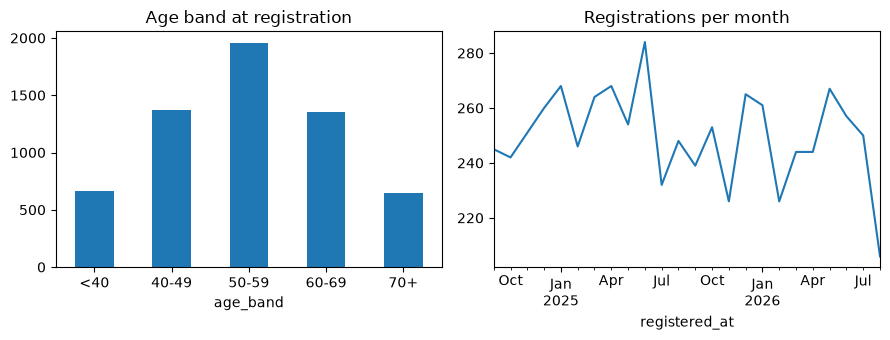

In [3]:
fig, ax = plt.subplots(1, 2)
patients.age_band.value_counts().sort_index().plot.bar(ax=ax[0], title="Age band at registration", rot=0)
patients.set_index("registered_at").resample("MS").size().plot(ax=ax[1], title="Registrations per month")
plt.tight_layout()

## 2. Appointments and the missed-visit label

An appointment is created at every visit. The label for Step 2 is **missed = no BP recorded within
[scheduled − 3 d, scheduled + 7 d]**. Only appointments whose window has closed are labelled.

In [4]:
appts = q('''
    SELECT a.id AS appointment_id, a.patient_id, a.facility_id, a.scheduled_date, a.status,
           a.device_created_at AS booked_at, (a.scheduled_date - a.device_created_at::date) AS lead_days
    FROM appointments a
''')
bps = q("SELECT patient_id, recorded_at::date AS d, systolic, diastolic, recorded_at FROM blood_pressures WHERE deleted_at IS NULL")
appts["scheduled_date"] = pd.to_datetime(appts.scheduled_date)
bps["d"] = pd.to_datetime(bps.d)

due = appts[appts.scheduled_date <= AS_OF - pd.Timedelta(days=7)].copy()
m = due[["appointment_id", "patient_id", "scheduled_date"]].merge(bps[["patient_id", "d"]], on="patient_id", how="left")
hit = (m.d >= m.scheduled_date - pd.Timedelta(days=3)) & (m.d <= m.scheduled_date + pd.Timedelta(days=7))
due["missed"] = ~hit.groupby(m.appointment_id).any().reindex(due.appointment_id).values
due = due.merge(patients[["patient_id", "facility", "distance_band", "gender", "age_band", "region", "reminder_consent"]], on="patient_id")
print(f"{len(due):,} labelled appointments; missed rate = {due.missed.mean():.1%}")

36,389 labelled appointments; missed rate = 29.1%


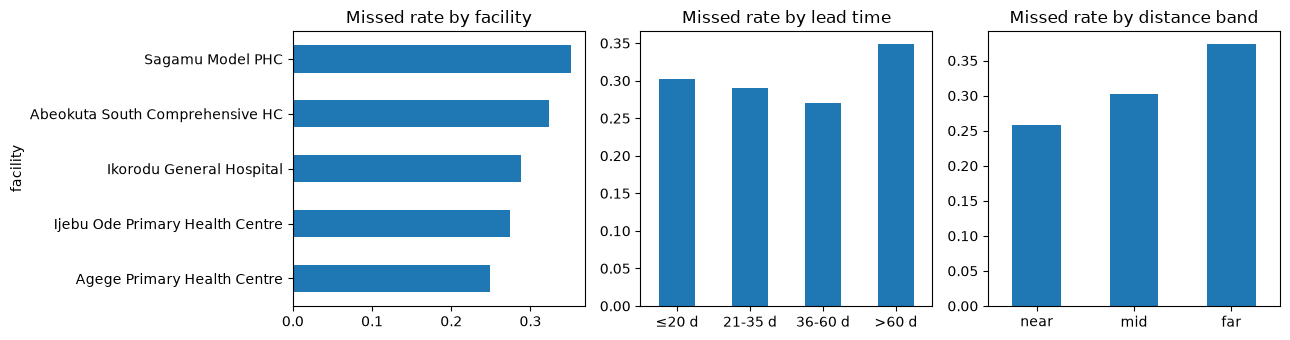

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
due.groupby("facility").missed.mean().sort_values().plot.barh(ax=ax[0], title="Missed rate by facility")
due["lead_band"] = pd.cut(due.lead_days, [0, 20, 35, 60, 400], labels=["≤20 d", "21-35 d", "36-60 d", ">60 d"])
due.groupby("lead_band").missed.mean().plot.bar(ax=ax[1], title="Missed rate by lead time", rot=0)
due.groupby("distance_band").missed.mean().reindex(["near", "mid", "far"]).plot.bar(ax=ax[2], title="Missed rate by distance band", rot=0)
for a in ax: a.set_xlabel("")
plt.tight_layout()

In [6]:
# Region shows a gap — but the generator gives region no causal effect. The gap is mediated by distance.
pd.concat({
    "by region": due.groupby("region").missed.mean().round(3),
    "far share": patients.groupby("region").distance_band.apply(lambda s: (s == "far").mean()).round(3),
}, axis=1)

,by region,far share
region,,
Lagos,0.269,0.116
Ogun,0.311,0.197
Oyo,0.314,0.328


In [7]:
# Within each distance band, the regional gap largely disappears
due.pivot_table(index="distance_band", columns="region", values="missed", aggfunc="mean").round(3).reindex(["near", "mid", "far"])

region,Lagos,Ogun,Oyo
distance_band,,,
near,0.243,0.277,0.272
mid,0.286,0.318,0.295
far,0.357,0.382,0.377


## 3. Overdue and lost to follow-up (program views)

under care: 4,750   overdue: 2,295 (48.3%)   with phone (overdue list): 1,900   LTFU: 900


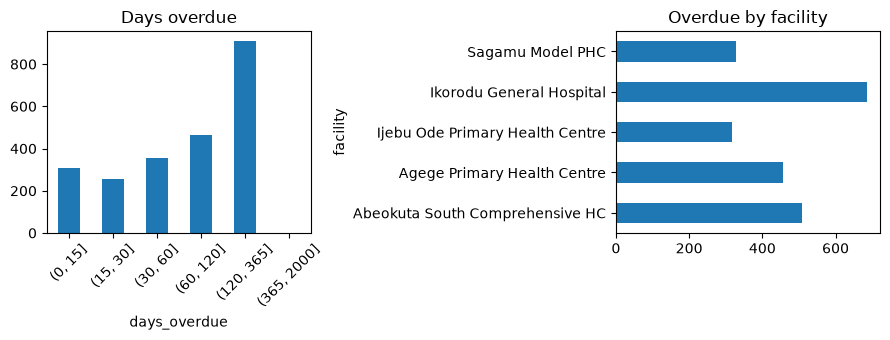

In [8]:
ov = q("SELECT * FROM overdue_patients")
uc = q("SELECT count(*) AS n FROM patients_under_care").n[0]
ltfu = q("SELECT count(*) AS n FROM lost_to_follow_up").n[0]
print(f"under care: {uc:,}   overdue: {len(ov):,} ({len(ov)/uc:.1%})   with phone (overdue list): {ov.has_phone.sum():,}   LTFU: {ltfu:,}")
fig, ax = plt.subplots(1, 2)
pd.cut(ov.days_overdue, [0, 15, 30, 60, 120, 365, 2000]).value_counts().sort_index().plot.bar(ax=ax[0], title="Days overdue", rot=45)
ov.merge(patients[["patient_id", "facility"]], on="patient_id").groupby("facility").size().plot.barh(ax=ax[1], title="Overdue by facility")
plt.tight_layout()

## 4. Blood pressure control

controlled (<140/90) at latest visit: 41.2%


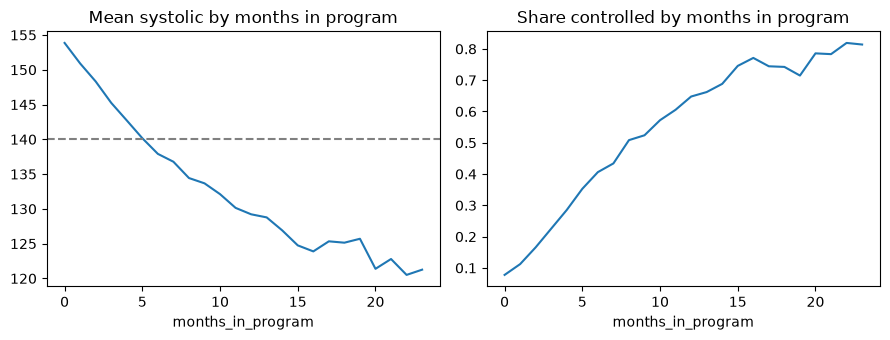

In [9]:
ctrl = q("SELECT controlled FROM bp_controlled_latest")
print(f"controlled (<140/90) at latest visit: {ctrl.controlled.mean():.1%}")
reg = patients.set_index("patient_id").registered_at
bps["months_in_program"] = ((bps.recorded_at - bps.patient_id.map(reg)).dt.days // 30).clip(0, 23)
trend = bps.groupby("months_in_program").agg(systolic=("systolic", "mean"), controlled=("systolic", lambda s: np.nan))
trend["controlled"] = bps.assign(c=(bps.systolic < 140) & (bps.diastolic < 90)).groupby("months_in_program").c.mean()
fig, ax = plt.subplots(1, 2)
trend.systolic.plot(ax=ax[0], title="Mean systolic by months in program"); ax[0].axhline(140, ls="--", c="grey")
trend.controlled.plot(ax=ax[1], title="Share controlled by months in program")
plt.tight_layout()

## 5. Overdue calls and what they achieve

Simple's effectiveness metric: **did the patient visit within 15 days of the call?**

In [10]:
calls = q('''
    SELECT c.appointment_id, c.patient_id, c.result_type, c.remove_reason, c.device_created_at AS called_at
    FROM call_results c
''')
calls["called_at"] = pd.to_datetime(calls.called_at)
mm = calls.merge(bps[["patient_id", "recorded_at"]], on="patient_id", how="left")
within = (mm.recorded_at > mm.called_at) & (mm.recorded_at <= mm.called_at + pd.Timedelta(days=15))
calls["returned_15d"] = within.groupby([mm.appointment_id, mm.called_at]).any().reindex(pd.MultiIndex.from_frame(calls[["appointment_id", "called_at"]])).values
display(calls.result_type.value_counts(normalize=True).round(3).to_frame("share"))
display(calls.groupby("result_type").returned_15d.mean().round(3).to_frame("returned within 15 days"))
display(calls.remove_reason.value_counts().to_frame("removed reasons"))

,share
result_type,
agreed_to_visit,0.506
remind_to_call_later,0.292
removed_from_overdue_list,0.202


,returned within 15 days
result_type,
agreed_to_visit,0.643
remind_to_call_later,0.229
removed_from_overdue_list,0.010


,removed reasons
remove_reason,
not_responding,455
invalid_phone_number,228
moved,165
refused_to_return,131
dead,61
public_hospital_transfer,52
other,47


## 6. SMS reminders and patient replies

Inbound replies are the raw material for the scheduling chatbot (Step 5). Intent labels come from the generator's truth file, which is never loaded into the database.

,,n
communication_type,direction,
appointment_reminder,outbound,26244
missed_visit_sms_reminder,outbound,7092
sms,inbound,9700
voip_call,outbound,5626


outbound delivery status: {'delivered': 0.703, 'completed': 0.133, 'sent': 0.086, 'failed': 0.067, 'no_answer': 0.012}
reply rate per outbound SMS: 29.1%


,language,body
41971,yo,mo ma wa
46108,pcm,abeg
40952,ha,wace rana zan zo?
12924,en,cant make it tomorrow
33789,ha,Wace rana zan zo?
35016,pcm,"No wahala, I go show"
47835,yo,"O da, ma wa lola"
39926,yo,Mo ma wa
9381,pcm,wetin time clinic dey open?
15115,en,Is Saturday possible?


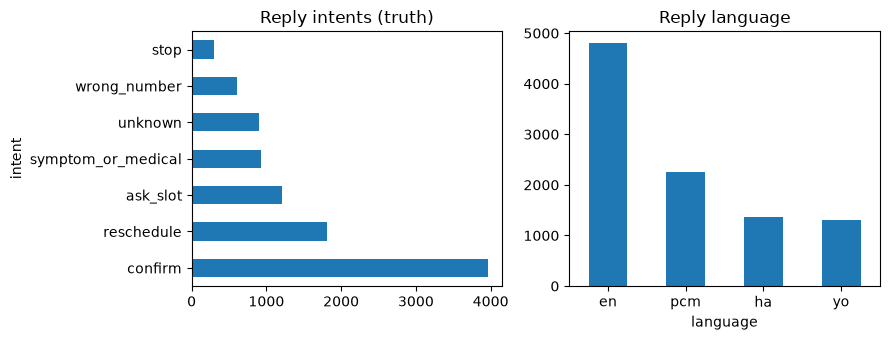

In [11]:
sms = q("SELECT communication_type, direction, delivery_status, language, body FROM communications")
display(sms.groupby(["communication_type", "direction"]).size().to_frame("n"))
out = sms[sms.direction == "outbound"]
print(f"outbound delivery status: {out.delivery_status.value_counts(normalize=True).round(3).to_dict()}")
print(f"reply rate per outbound SMS: {(sms.direction == 'inbound').sum() / (out.communication_type != 'voip_call').sum():.1%}")
intents = pd.read_csv(ROOT / "data/synth/out/_truth_sms_intents.csv")
fig, ax = plt.subplots(1, 2)
intents.intent.value_counts().plot.barh(ax=ax[0], title="Reply intents (truth)")
intents.language.value_counts().plot.bar(ax=ax[1], title="Reply language", rot=0)
plt.tight_layout()
sms[sms.direction == "inbound"].sample(10, random_state=0)[["language", "body"]]

## 7. Takeaways for modelling

- **Label balance.** Roughly one in four labelled appointments is missed — imbalanced but not extreme; PR-AUC and precision at worklist capacity matter more than accuracy.
- **Strong signals.** Distance band, facility, and prior misses (to be built in Step 2) all separate the classes.
- **Lead time is confounded.** Very short intervals (≤20 d) are given to *uncontrolled* patients, who also miss more, so the raw curve is U-shaped; the >60 d group is still the riskiest. The model needs control status and interval together, not lead time alone.
- **Fairness trap.** Region shows a raw gap that disappears within distance band. Region must stay out of the features and appear only in the audit (`notebooks/03_fairness_and_calibration.ipynb`).
- **Operational reality.** About half the under-care patients are overdue at any time and only ~half of overdue patients with a phone get a call — capacity is the constraint the worklist (Step 3) must respect.
- **Chatbot data.** Replies are short, multilingual and noisy; ~13% confirm, ~6% ask to reschedule, ~3% describe symptoms that must be routed to a human.